In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("global_ecommerce_sales.csv")

In [6]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [7]:
df.shape

(2000, 15)

In [8]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [14]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64


In [11]:
df.describe()

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
std,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593
min,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000


In [15]:
print("\nDuplicate Records:")
print(df.duplicated().sum())


Duplicate Records:
0


In [17]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
print(df.dtypes)

order_id             object
order_date           object
customer_name        object
customer_segment     object
country              object
region               object
product_category     object
product_name         object
quantity              int64
unit_price          float64
discount_percent      int64
total_sales         float64
shipping_cost       float64
profit              float64
payment_method       object
dtype: object


In [25]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['order_id', 'order_date', 'customer_name', 'customer_segment',
       'country', 'region', 'product_category', 'product_name', 'quantity',
       'unit_price', 'discount_percent', 'total_sales', 'shipping_cost',
       'profit', 'payment_method'],
      dtype='object')

In [27]:
Q1 = df["total_sales"].quantile(0.25)
Q3 = df["total_sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-296.76 604.54


In [28]:
outliers = df[(df["total_sales"] < lower_bound) |
              (df["total_sales"] > upper_bound)]

print(outliers.shape)

(190, 15)


In [29]:
df = df[(df["total_sales"] >= lower_bound) &
        (df["total_sales"] <= upper_bound)]

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1810 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1810 non-null   object        
 1   order_date        1810 non-null   datetime64[ns]
 2   customer_name     1810 non-null   object        
 3   customer_segment  1810 non-null   object        
 4   country           1810 non-null   object        
 5   region            1810 non-null   object        
 6   product_category  1810 non-null   object        
 7   product_name      1810 non-null   object        
 8   quantity          1810 non-null   int64         
 9   unit_price        1810 non-null   float64       
 10  discount_percent  1810 non-null   int64         
 11  total_sales       1810 non-null   float64       
 12  shipping_cost     1810 non-null   float64       
 13  profit            1810 non-null   float64       
 14  payment_method    1810 non-nu

In [32]:
df.to_csv(r"C:\Users\Anu's world\Downloads\cleaned_global_ecommerce_sales.csv",
          index=False)
print("Data Cleaning Completed Successfully")


Data Cleaning Completed Successfully


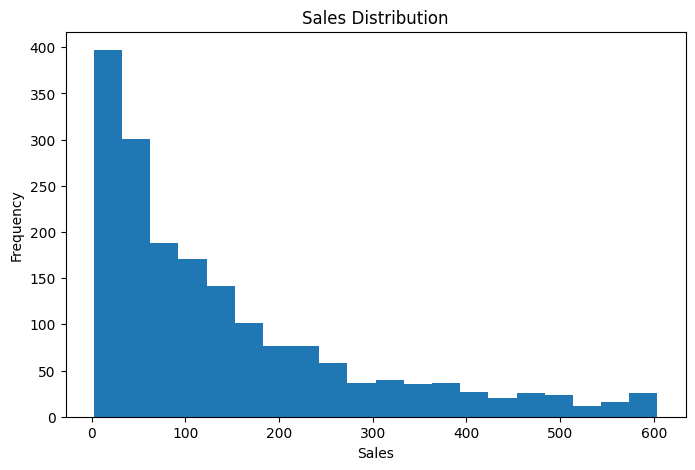

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["total_sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

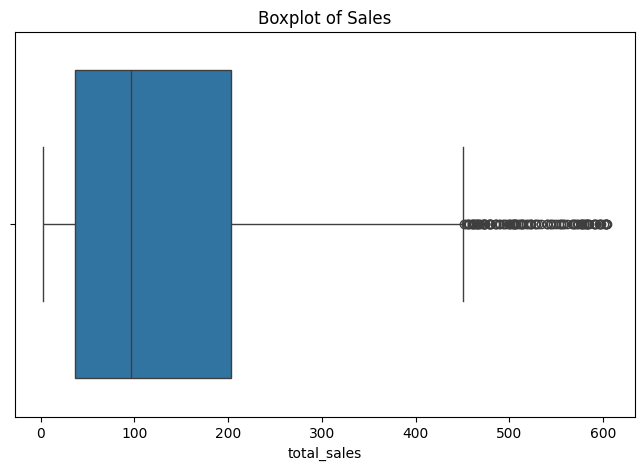

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["total_sales"])
plt.title("Boxplot of Sales")
plt.show()

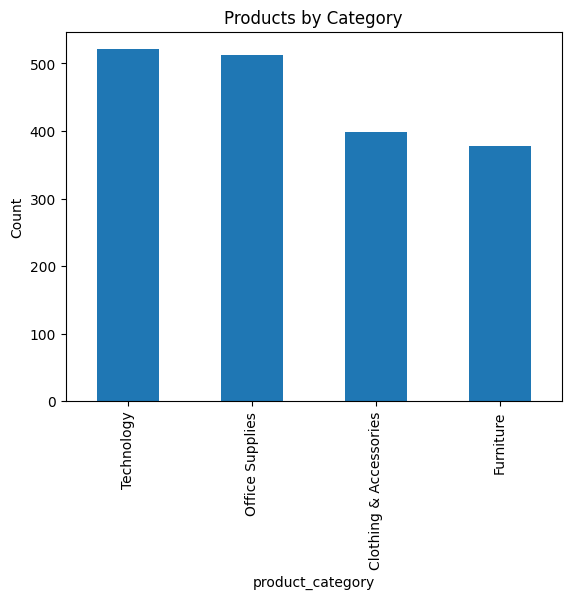

In [37]:
df["product_category"].value_counts().plot(kind="bar")
plt.title("Products by Category")
plt.xlabel("product_category")
plt.ylabel("Count")
plt.show()

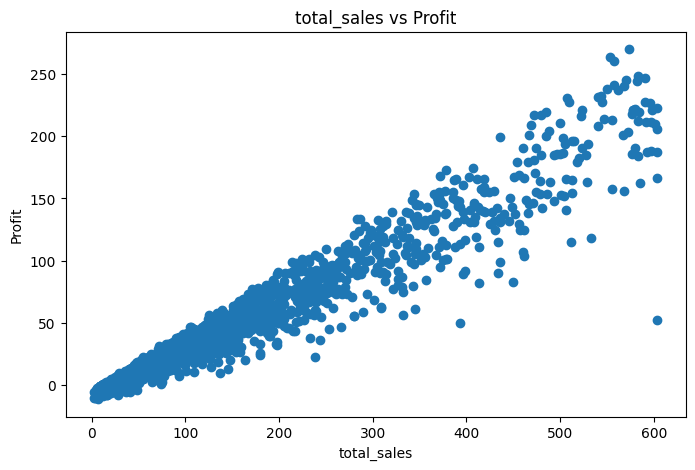

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df["total_sales"], df["profit"])
plt.xlabel("total_sales")
plt.ylabel("Profit")
plt.title("total_sales vs Profit")
plt.show()

In [41]:
corr = df.select_dtypes(include=np.number).corr()
corr

,quantity,unit_price,discount_percent,total_sales,shipping_cost,profit
quantity,1.000000,-0.208241,0.012233,0.442940,0.740684,0.431358
unit_price,-0.208241,1.000000,0.048363,0.604609,-0.144620,0.547834
discount_percent,0.012233,0.048363,1.000000,-0.047870,0.012435,-0.189241
total_sales,0.442940,0.604609,-0.047870,1.000000,0.324894,0.967071
shipping_cost,0.740684,-0.144620,0.012435,0.324894,1.000000,0.277673
profit,0.431358,0.547834,-0.189241,0.967071,0.277673,1.000000


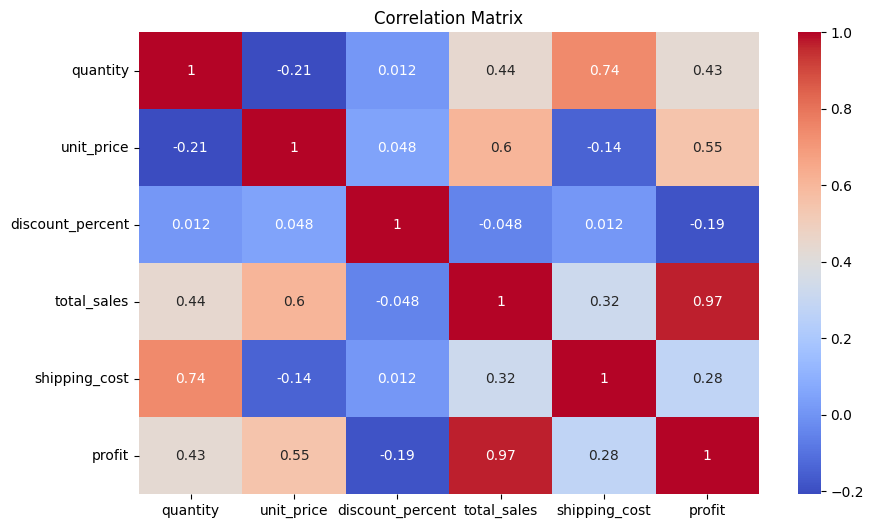

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [43]:
df.groupby("product_name")["total_sales"].sum().sort_values(ascending=False).head(10)

product_name
Mesh Back Task Chair             14794.78
Portable External SSD 1TB        13159.11
Bookshelf 5-Tier                 12115.49
Floating Wall Shelves Set        11767.30
Folding Table Portable           11449.28
Webcam HD 1080p                  10927.15
Mechanical Gaming Keyboard       10308.45
Wireless Ergonomic Mouse          9995.39
Wireless Bluetooth Headphones     9849.31
Travel Backpack 30L               9699.77
Name: total_sales, dtype: float64

In [46]:
df.groupby("product_category")["total_sales"].sum().sort_values(ascending=False)

product_category
Technology                93738.78
Furniture                 90424.83
Clothing & Accessories    57730.36
Office Supplies           19390.81
Name: total_sales, dtype: float64

In [48]:
df.groupby("country")["total_sales"].sum().sort_values(ascending=False)

country
Mexico            27442.29
United States     25891.93
Canada            21939.94
Germany           15298.10
Australia         15077.80
Japan             14869.54
United Kingdom    14865.04
France            13763.59
China             13141.32
India             11337.84
Italy             11321.78
Spain             11274.55
South Korea       10875.62
Saudi Arabia       9660.15
Brazil             9342.43
Argentina          8690.27
South Africa       8199.30
Colombia           6508.44
Nigeria            6188.73
UAE                5596.12
Name: total_sales, dtype: float64

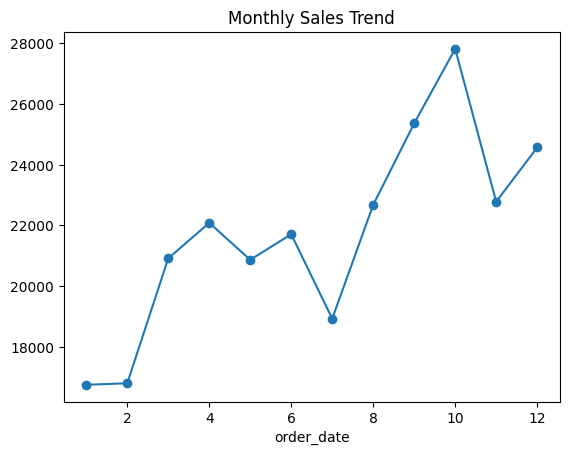

In [49]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = df.groupby(df["order_date"].dt.month)["total_sales"].sum()

monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.show()